# Main experiments setup

## Robust optimization approach

In [1]:
import json
from pathlib import Path
import numpy as np

from visualization import ExperimentVisualizer
from run_experiments import run_robust_experiments, run_stochastic_experiments, run_scaling_experiments

In [2]:
N_VALUES = list(range(5, 16, 5))
NUM_INSTANCES = 100
K = 30
ALPHA = 0.9
SEED = 42

visualizer = ExperimentVisualizer()

In [3]:
def save_results(result: dict, out_path: Path):
    with open(out_path, "w") as f:
        json.dump(result, f)

In [4]:
robust_results = {}
for n in N_VALUES:
    print(f"\nRunning robust experiments for n={n}")
    result = run_robust_experiments(n)
    robust_results[n] = result

save_results(robust_results, Path("experiments/robust_results.json"))


Running robust experiments for n=5
Set parameter LicenseID to value 2799306
Restricted license - for non-production use only - expires 2027-11-29
  Gamma=1: Mean=99.09, Std=16.07, Avg Time=0.002s
  Gamma=2: Mean=103.38, Std=16.81, Avg Time=0.002s
  Gamma=3: Mean=106.68, Std=17.24, Avg Time=0.002s
  Gamma=4: Mean=109.31, Std=17.63, Avg Time=0.002s
  Gamma=5: Mean=111.31, Std=17.85, Avg Time=0.002s
  Gamma=6: Mean=111.31, Std=17.85, Avg Time=0.002s

Running robust experiments for n=10
Set parameter LicenseID to value 2799306
Restricted license - for non-production use only - expires 2027-11-29
  Gamma=1: Mean=154.11, Std=14.28, Avg Time=0.004s
  Gamma=2: Mean=158.28, Std=14.78, Avg Time=0.004s
  Gamma=3: Mean=161.83, Std=15.07, Avg Time=0.004s
  Gamma=4: Mean=165.02, Std=15.34, Avg Time=0.005s
  Gamma=5: Mean=167.91, Std=15.54, Avg Time=0.005s
  Gamma=6: Mean=170.52, Std=15.71, Avg Time=0.005s

Running robust experiments for n=15
Set parameter LicenseID to value 2799306
Restricted licen

### Average in-sample performance

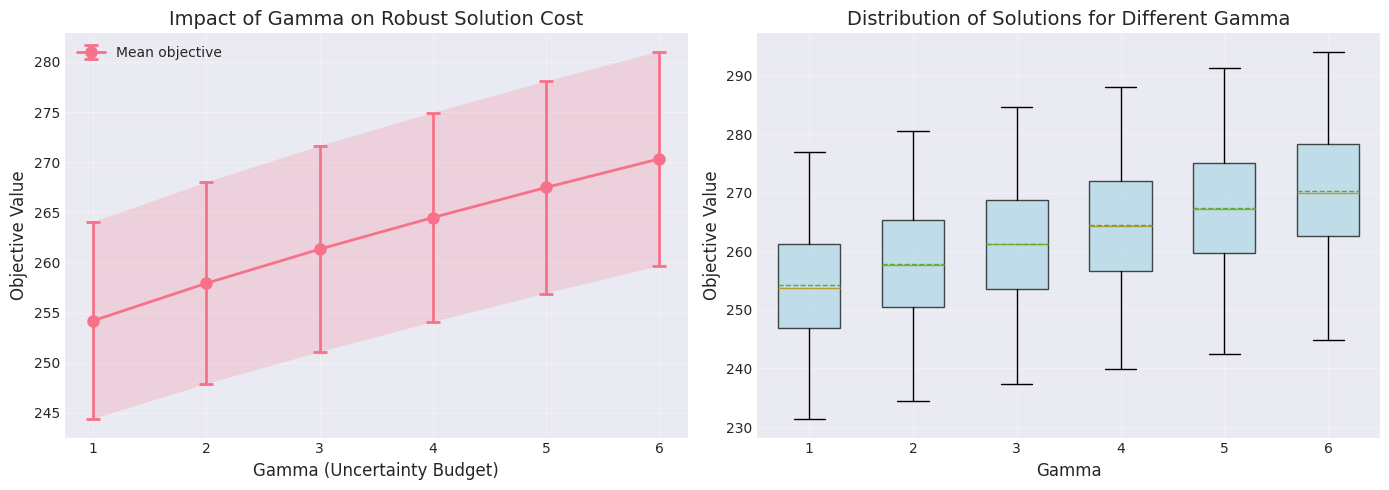

In [5]:
n = 20
results = robust_results[n]
gamma_values = sorted(results.keys())

objectives = [results[g]["in_sample"] for g in gamma_values]
visualizer.plot_robust_gamma_analysis(gamma_values, objectives)

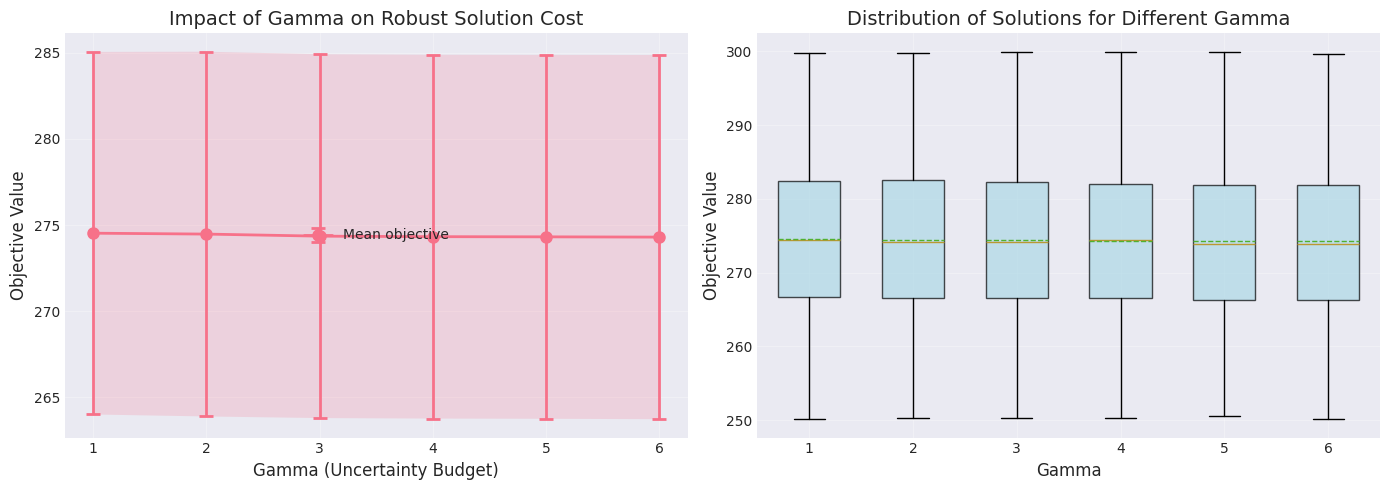

In [6]:
objectives = [results[g]["oos"] for g in gamma_values]
visualizer.plot_robust_gamma_analysis(gamma_values, objectives)

## Stochastic optimization approach

In [4]:
stochastic_rn_results = {}
stochastic_ra_results = {}

for n in N_VALUES:
    print(f"\nRunning stochastic experiments for n={n}")
    rn_result, ra_result = run_stochastic_experiments(n, k=30, alpha_values=[0.4, 0.5])
    stochastic_rn_results[n] = rn_result
    stochastic_ra_results[n] = ra_result

save_results(stochastic_rn_results, Path("experiments/stochastic_risk_neutral_results.json"))
save_results(stochastic_ra_results, Path("experiments/stochastic_risk_averse_results.json"))


Running stochastic experiments for n=5
Set parameter LicenseID to value 2799306
Restricted license - for non-production use only - expires 2027-11-29

Solving Risk-Neutral problems...
RN: mean=54.99, std=0.10, CVaR=57.51

Solving Risk-Averse problems with α=0.4...
  α=0.4: mean=55.01, std=0.10, CVaR=57.04

Solving Risk-Averse problems with α=0.5...
  α=0.5: mean=55.01, std=0.09, CVaR=57.53

Running stochastic experiments for n=10
Set parameter LicenseID to value 2799306
Restricted license - for non-production use only - expires 2027-11-29

Solving Risk-Neutral problems...
RN: mean=185.06, std=0.20, CVaR=189.94

Solving Risk-Averse problems with α=0.4...
  α=0.4: mean=185.03, std=0.17, CVaR=188.98

Solving Risk-Averse problems with α=0.5...
  α=0.5: mean=185.00, std=0.21, CVaR=189.88

Running stochastic experiments for n=15
Set parameter LicenseID to value 2799306
Restricted license - for non-production use only - expires 2027-11-29

Solving Risk-Neutral problems...
RN: mean=389.99, st

### Risk-Neutral vs Risk-Averse

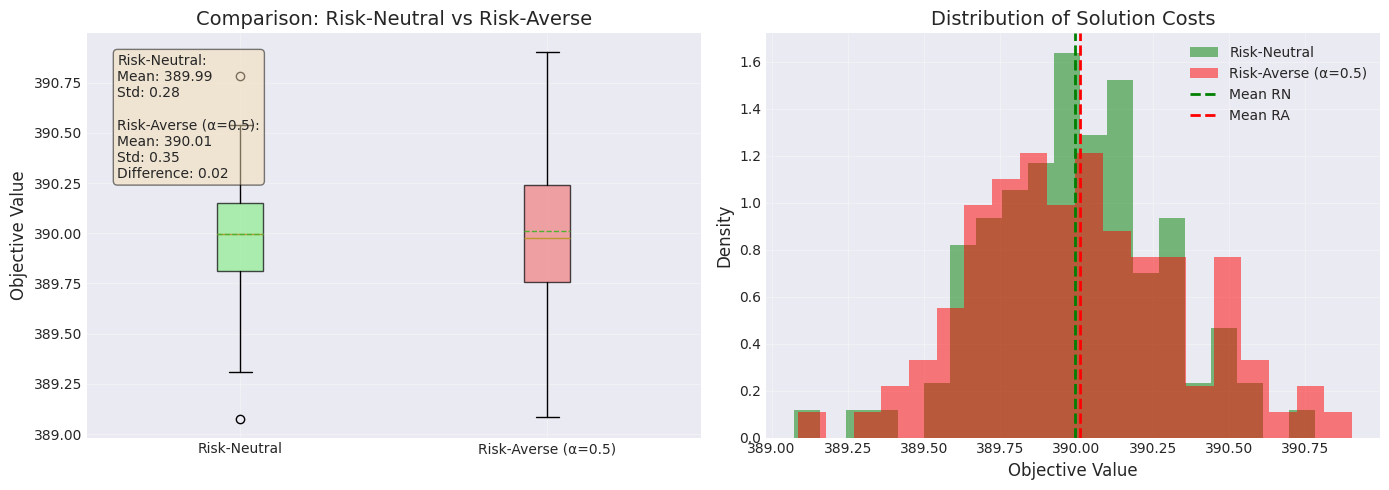

In [10]:
n = 15
alpha = 0.5

rn_objs = stochastic_rn_results[n]["mean_list"]
ra_objs = stochastic_ra_results[n][alpha]["mean_list"]

visualizer.plot_stochastic_comparison(rn_objs, ra_objs, alpha=alpha)

### Alpha sensitivity

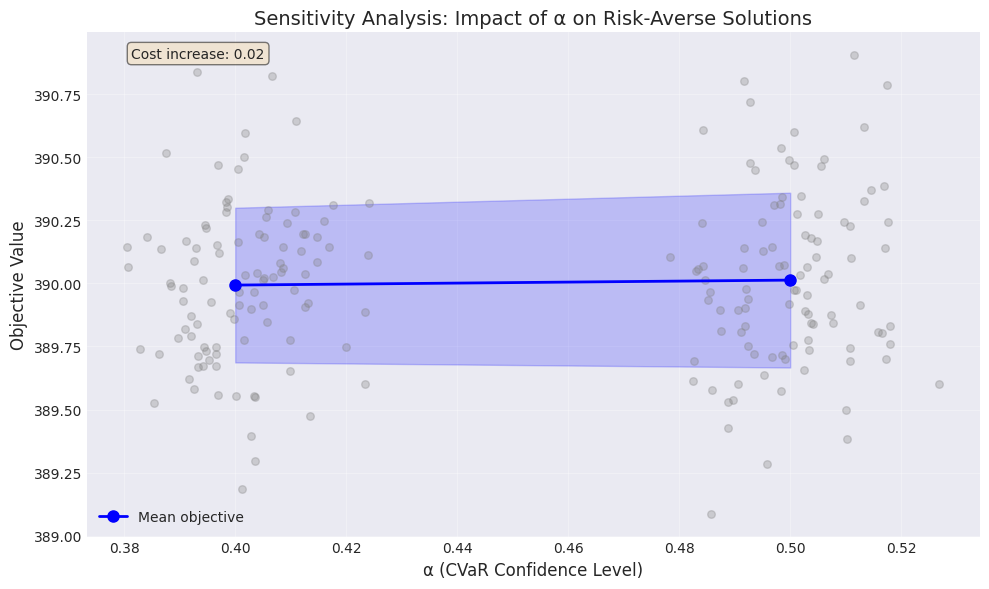

In [11]:
alpha_values = sorted(stochastic_ra_results[n].keys())
objectives = [stochastic_ra_results[n][a]["mean_list"] for a in alpha_values]

visualizer.plot_alpha_sensitivity(alpha_values, objectives)

For tail risk

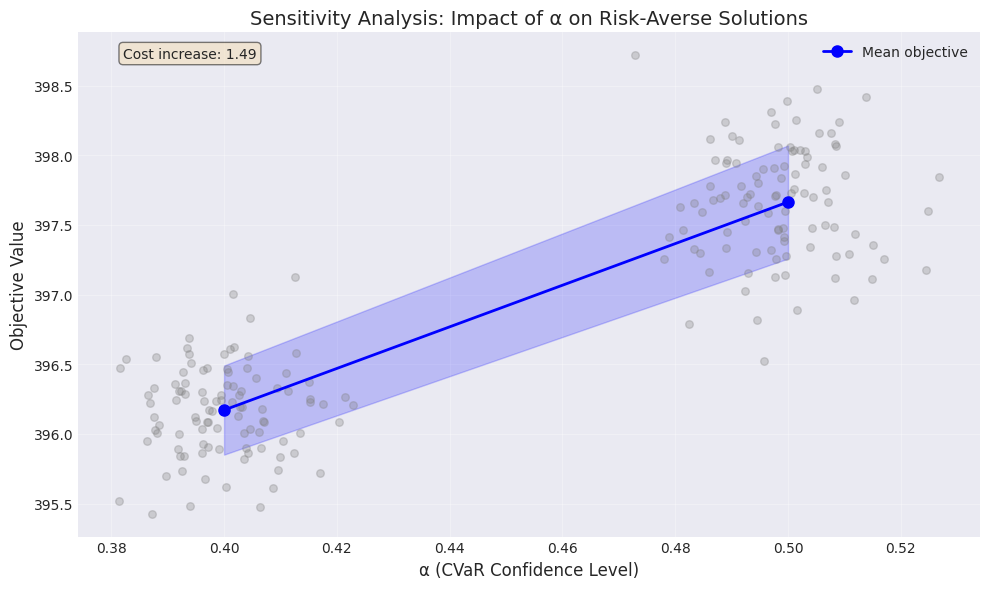

In [12]:
objectives = [stochastic_ra_results[n][a]["cvar_list"] for a in alpha_values]
visualizer.plot_alpha_sensitivity(alpha_values, objectives)

### Out of sample performance

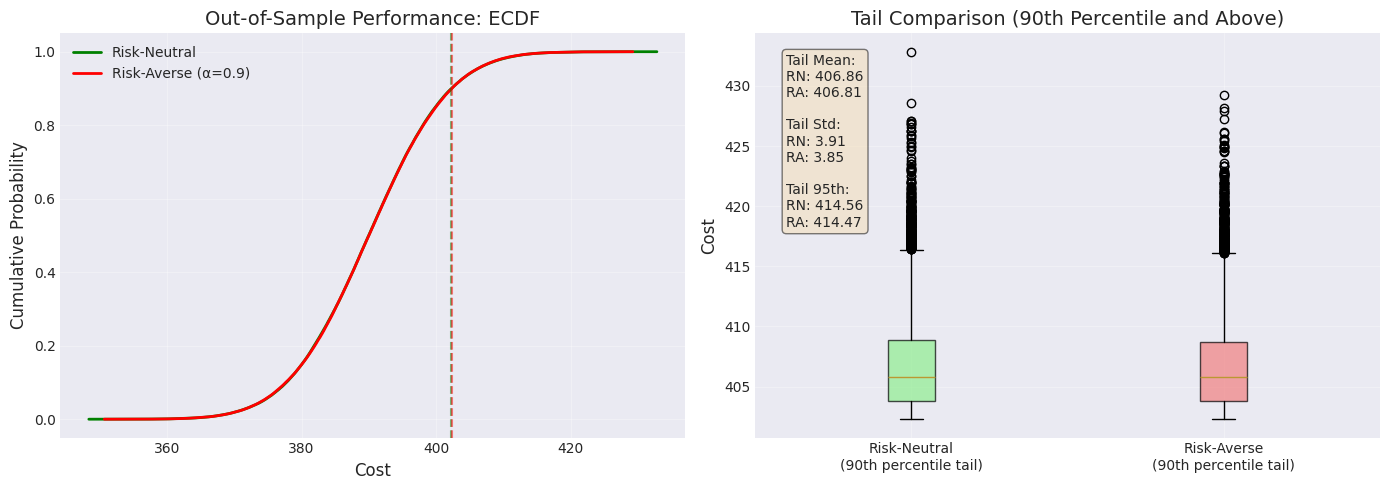

In [13]:
rn_costs = stochastic_rn_results[n]["all_costs"]
ra_costs = stochastic_ra_results[n][alpha]["all_costs"]

visualizer.plot_out_of_sample_performance(rn_costs, ra_costs)

### Summary

In [14]:
summary = {}

summary["Risk-Neutral"] = {
    "mean": np.mean(stochastic_rn_results[n]["mean_list"]),
    "std": np.std(stochastic_rn_results[n]["mean_list"]),
    "cvar": np.mean(stochastic_rn_results[n]["cvar_list"]),
    "solve_time": np.mean(stochastic_rn_results[n]["solve_times"]),
}

for alpha, res in stochastic_ra_results[n].items():
    summary[f"Risk-Averse α={alpha}"] = {
        "mean": res["mean"],
        "std": res["std"],
        "cvar": res["cvar"],
        "solve_time": res["solve_time_mean"],
    }

visualizer.create_summary_table(summary)


SUMMARY OF EXPERIMENT RESULTS
Method                    cvar         mean         solve_time   std         
--------------------------------------------------------------------------------
Risk-Neutral              397.64          389.99          0.003         0.28         
Risk-Averse α=0.4         396.17          389.99          0.252         0.31         
Risk-Averse α=0.5         397.66          390.01          0.355         0.35         


## Scaling experiment

In [15]:
sizes=[5, 10, 15]
robust_scaling_results, stochastic_scaling_results = run_scaling_experiments(sizes=sizes, num_instances_per_size=10)

save_results(robust_scaling_results, Path("experiments/robust_scaling_results.json"))
save_results(stochastic_scaling_results, Path("experiments/stochastic_scaling_results.json"))

Set parameter LicenseID to value 2799306
Restricted license - for non-production use only - expires 2027-11-29



Testing size n=5...
  Processed 1/10
  Processed 6/10
  n=5: Avg Time=0.002s, Avg Obj=106.10

Testing size n=10...
  Processed 1/10
  Processed 6/10
  n=10: Avg Time=0.004s, Avg Obj=158.41

Testing size n=15...
  Processed 1/10
  Processed 6/10
  n=15: Avg Time=0.009s, Avg Obj=213.89

Testing size n=5...
  n=5: RN Time=0.001s, RA Time=0.010s

Testing size n=10...
  n=10: RN Time=0.002s, RA Time=0.194s

Testing size n=15...
  n=15: RN Time=0.003s, RA Time=3.637s


In [17]:
robust_2d = [
    [r for r in robust_scaling_results if r['n'] == n]
    for n in sizes
]

rn_2d = [
    [r for r in stochastic_scaling_results 
     if r['n'] == n and r['type'] == 'risk_neutral']
    for n in sizes
]

ra_2d = [
    [r for r in stochastic_scaling_results 
     if r['n'] == n and r['type'] == 'risk_averse']
    for n in sizes
]

### Robust

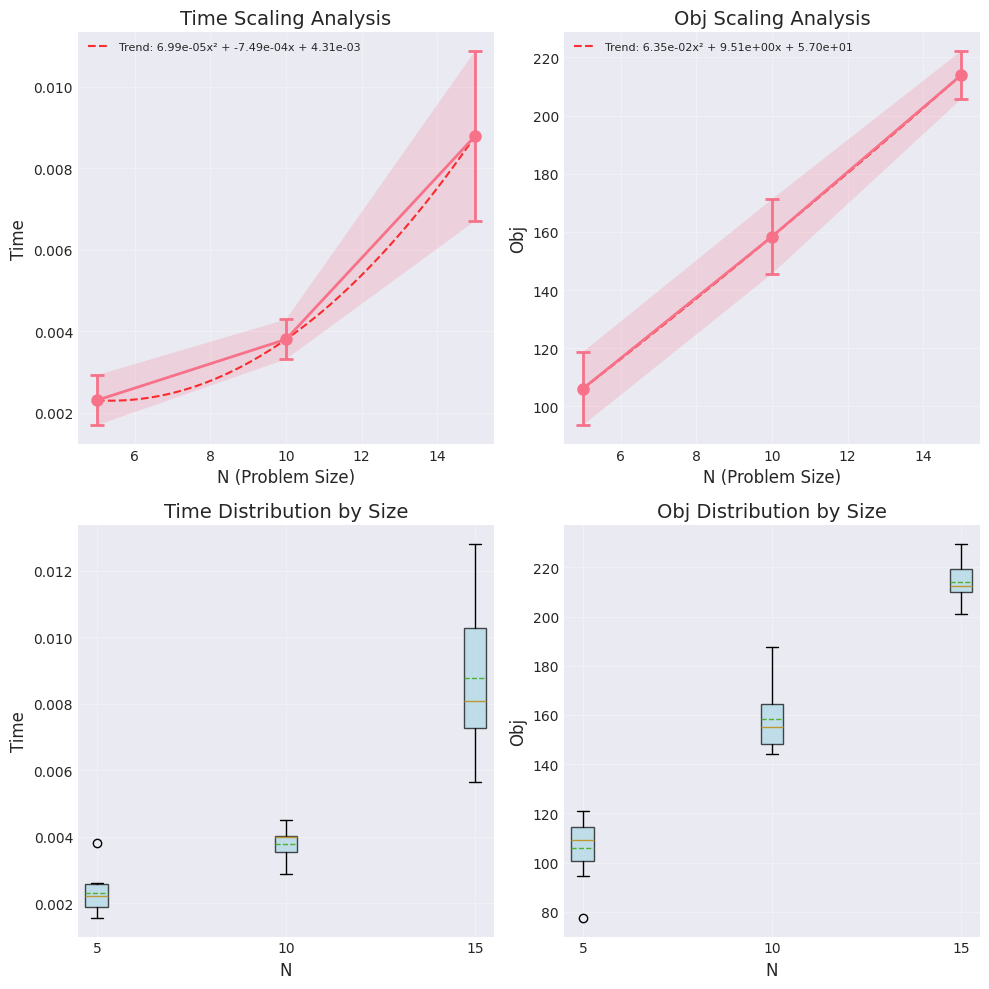

In [18]:
visualizer.plot_scaling_analysis(robust_2d)

### Stochastic Risk-Neutral

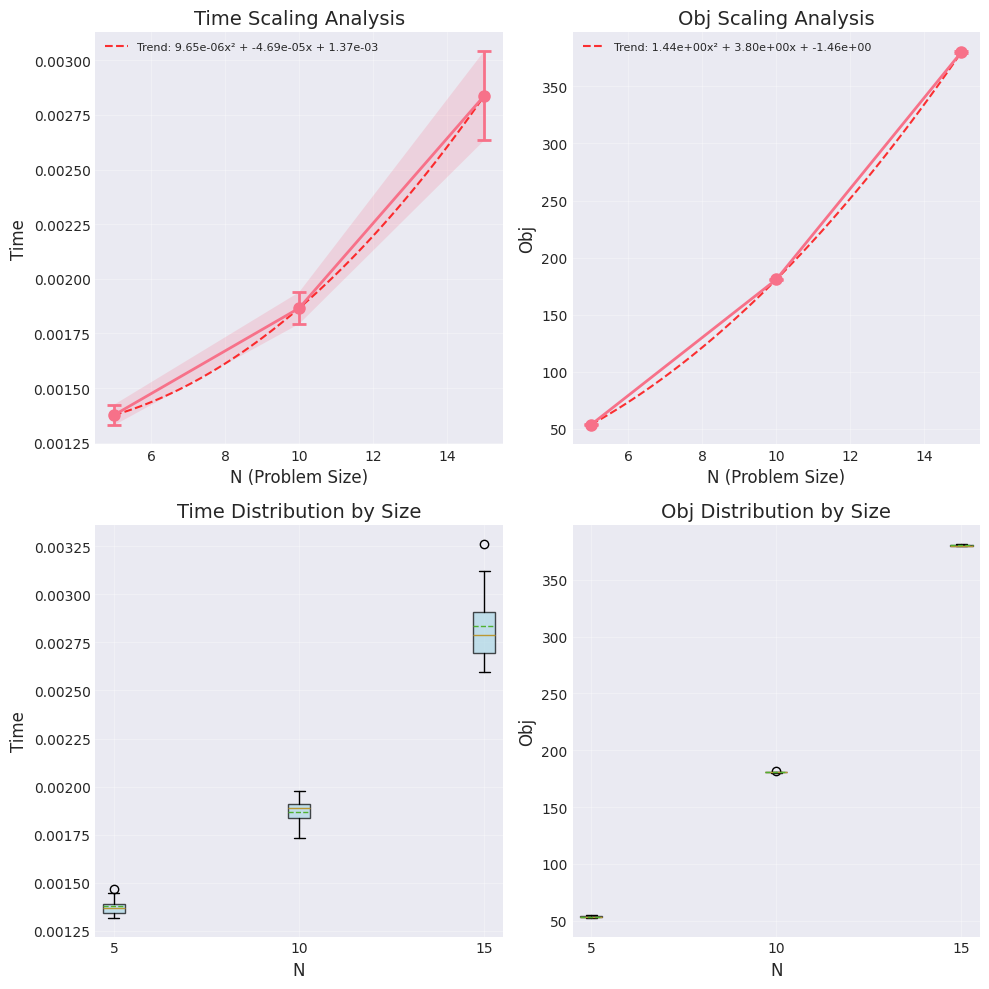

In [19]:
visualizer.plot_scaling_analysis(rn_2d)

### Stochastic Risk-Averse

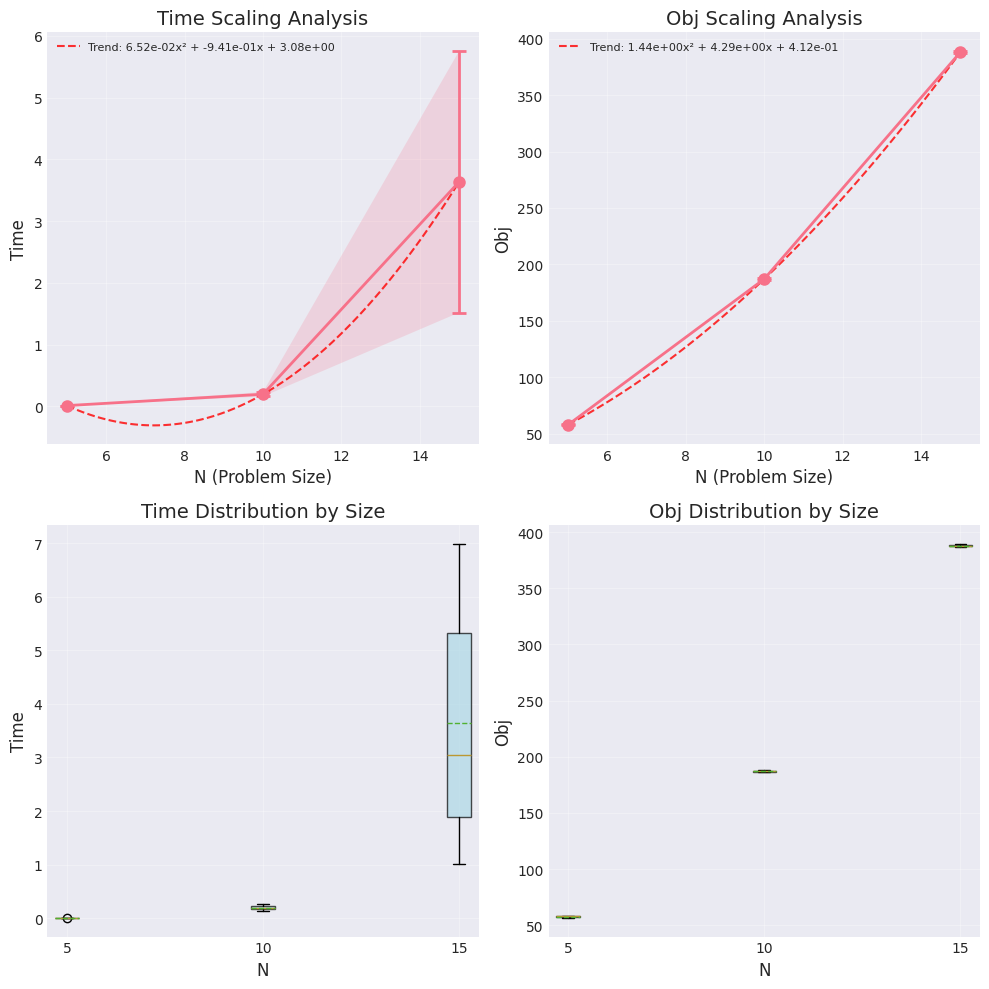

In [20]:
visualizer.plot_scaling_analysis(ra_2d)